## STEP 1: MODELO HEPATITIS B 0D

El sistema está formado por la evolución temporal (y espacial aunque para esta primera parte se ha omitido) de las siguientes variables:
- q1 = q1(t): cantidad de virus
- q2 = q2(t): cantidad de células T las cuales se pueden dividir en:

  - Th = Th(t): cantidad de células T helper
  - Tc = Tc(t): cantidad de células T cytotoxic

- q3 = q3(t): cantidad de citoquinas

Cada una de estas variables se relaciona con las demás a través de una serie de mecanismos (M) de replicación, activación y eliminación.

<p align="center">
<img src="https://cdn.ncbi.nlm.nih.gov/pmc/blobs/b6b6/11252204/36788d1a5e36/285_2024_2126_Fig1_HTML.jpg" width="200">
</p>

El modelo puede expresarse como un sistema de ecuaciones:

$$ \frac{d}{dt} \left[ \begin{array}{c} q_1 \\ Th \\ Tc \\ q_3 \end{array} \right] = \left[ \begin{array}{c} q_1 \\ Th \\ Tc \\ q_3 \end{array} \right] $$

O escrito de otra manera más compacta:

$$ \frac{d}{dt}  Y  =  R(Y) $$



### 1. Importamos librerías

In [13]:
from sympy import *                 # Librería para trabajo simbólico
import numpy as np                  # Librería para cálculo numérico
import math                         # Librería para utilizar símbolos matemáticos como el número pi, que se escribe como math.pi
import matplotlib.pyplot as plt     # Librería para poder dibujar gráficas
from scipy.integrate import odeint

### 2. Damos valor a las constantes

In [14]:
# Constantes
a1 = 1.0                # desintegración natural del virus (q1)
C1 = 1.0                # capacidad de q1 (virus)
epsilon = 0.05          # parámetro efecto Allee
kappa = 0.01            # parámetro efecto Allee
a5 = 0.08               # efectividad de las células T
a2h = 2.0               # regula la entrada de células Th a través del "portal field" en función del virus (q1) total en un tiempo t
Cth = 8.0               # capacidad de Th 
a6h = 0.2               # tasa de decaimiento Th 
a6c = 0.2               # tasa de decaimiento Tc 
Ctc = 15.0              # capacidad de Tc 
a3 = 0.8                # producción de citoquinas (q3), por el virus y las células Th
a_nd = 0.6              # contante de desintegración de las citoquinas (q3)
a2c = 2.0               # regula la entrada de células Tc

### 3. Definimos sistemas intermedios (funciones f)

In [15]:
def f1M1(q1):
    return a1*q1*(C1-q1)*((q1-epsilon)/(q1+kappa)) 

def f1M5(q1,Tc):
    return -a5*q1*Tc

def fthM2(q1,Th):
    return a2h*(Cth-Th)*q1

def fthM6(q1,Th):
    return -a6h*Th*(C1-q1)

def ftcM2(q1,Tc):
    return a2c*(Ctc-Tc)*q1

def ftcM6(q1,Tc):
    return -a6c*Tc*(C1-q1)

def f3M3(q1,Th,q3):
    return a3*Th*q1-a_nd*q3

### 4. Definimos vector R(Y)

In [16]:
def rhs(Y, t):
    q1, Th, Tc, q3 = Y # variables a resolver
    dq1dt = f1M1(q1) + f1M5(q1,Tc)          # virus (q1)
    dthdt = fthM2(q1,Th) + fthM6(q1,Th)     # células T helper (Th)
    dtcdt = ftcM2(q1,Tc) + ftcM6(q1,Tc)     # células T cytotoxic (Tc)
    dq3dt = f3M3(q1,Th,q3)                  # citoquinas (q3)
    return dq1dt, dthdt, dtcdt, dq3dt

# tiene que ser sin corchetes para que no de error en odeint

### 5. Definimos condiciones iniciales

Añadir las condiciones iniciales:

In [17]:
#condicion inicial para cada variable
q1_0 = 0.1 # cantidad inicial de virus
Th_0 = 0.0 # cantidad inicial Th 
Tc_0 = 0.0 # cantidad inicial Tc
q3_0 = 0.0 # cantidad inicial de citoquinas

Y0 = [q1_0, Th_0, Tc_0, q3_0] # vector de estados inicial

# sería lo mismo que poner => Y0 = [1.0, 0.0, 0.0, 0.0]

### 6. Definimos vector de tiempos

Vamos a definir un vector de tiempos en el que resolver la ecuación:

In [18]:
t = np.linspace(0, 50, 1000) # tiempos en los que se calcula la solución

### 7. Resolución de la ecuación con SciPy

Y finalmente se resuelve la ecuación utilizando un integrador temporal predefinido ```odeint```

La solución se almacena en **sol**, que será un array de 2 dimensiones

In [19]:
#solving the system
sol = odeint(rhs, Y0, t) # llamada a una función de Python que resuelvene el sistema de ODEs

### 8. Representaciones gráficas

#### 8.1 Variables de estado con respecto al tiempo

Como no se ha tenido en cuenta la difusión el virus no se expande, se extinguen rápido todas las variables.

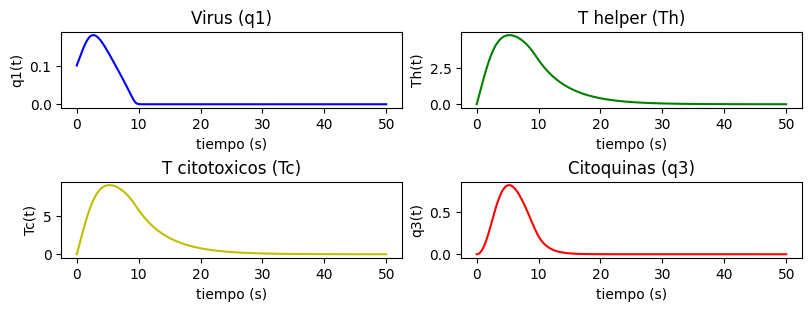

In [20]:
# Ploting the crosss section for Tmax
fig, axs = plt.subplots(2,2,figsize=(8, 3), constrained_layout=True)

ax1, ax2, ax3, ax4 = axs[0,0], axs[0,1], axs[1,0], axs[1,1]

ax1.plot(t, sol[:, 0], 'b', label='q1(t)')
ax2.plot(t, sol[:, 1], 'g', label='Th(t)')
ax3.plot(t, sol[:, 2], 'y', label='Tc(t)')
ax4.plot(t, sol[:, 3], 'r', label='q3(t)')

ax1.set_title("Virus (q1)")
ax1.set_xlabel("tiempo (s)")
ax1.set_ylabel("q1(t)")

ax2.set_title("T helper (Th)")
ax2.set_xlabel("tiempo (s)")
ax2.set_ylabel("Th(t)")

ax3.set_title("T citotoxicos (Tc)")
ax3.set_xlabel("tiempo (s)")
ax3.set_ylabel("Tc(t)")

ax4.set_title("Citoquinas (q3)")
ax4.set_xlabel("tiempo (s)")
ax4.set_ylabel("q3(t)")

# GUARDAR IMAGEN PNG A 300 DPI
fig.savefig(
    "equilibrio_virus.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

Text(0.5, 1.0, 'Evolución temporal de cada variable')

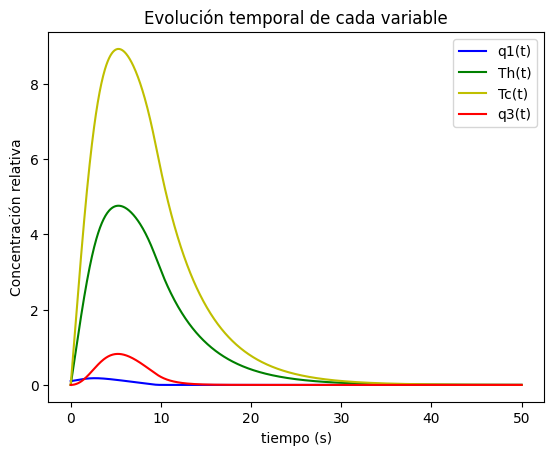

In [21]:
# Gráficas temporales 
plt.plot(t, sol[:, 0], 'b', label='q1(t)')
plt.plot(t, sol[:, 1], 'g', label='Th(t)')
plt.plot(t, sol[:, 2], 'y', label='Tc(t)')
plt.plot(t, sol[:, 3], 'r', label='q3(t)')

plt.xlabel("tiempo (s)")
plt.ylabel("Concentración relativa")
plt.legend(loc='upper right')
plt.title("Evolución temporal de cada variable")

#### 8.2 Diagrama de fase

Esto es para hacer un diagrama de fases más visual (representar una solución frente a otra):

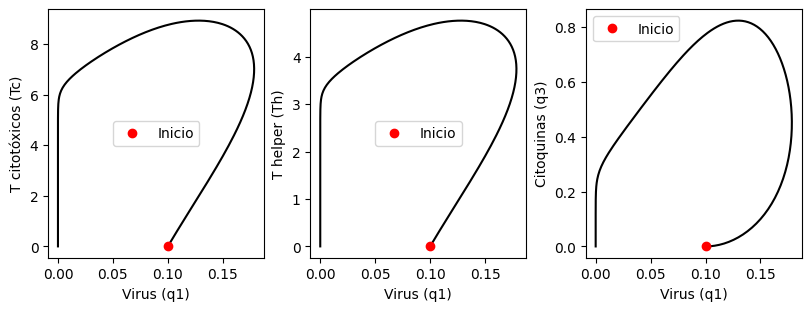

In [22]:
# Diagrama de fase
fig, axs = plt.subplots(1, 3, figsize=(8, 3), constrained_layout=True)

axs[0].plot(sol[:, 0], sol[:, 2], 'k')
axs[0].plot(sol[0, 0], sol[0, 2], 'or', label="Inicio")
axs[0].set_xlabel("Virus (q1)")
axs[0].set_ylabel("T citotóxicos (Tc)")
axs[0].legend()

axs[1].plot(sol[:, 0], sol[:, 1], 'k')
axs[1].plot(sol[0, 0], sol[0, 1], 'or', label="Inicio")
axs[1].set_xlabel("Virus (q1)")
axs[1].set_ylabel("T helper (Th)")
axs[1].legend()

axs[2].plot(sol[:, 0], sol[:, 3], 'k')
axs[2].plot(sol[0, 0], sol[0, 3], 'or', label="Inicio")
axs[2].set_xlabel("Virus (q1)")
axs[2].set_ylabel("Citoquinas (q3)")
axs[2].legend()

# GUARDAR IMAGEN PNG A 300 DPI
fig.savefig(
    "equilibrio_virus_phase.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

Text(0.5, 1.0, 'Fase espacio de cada variable')

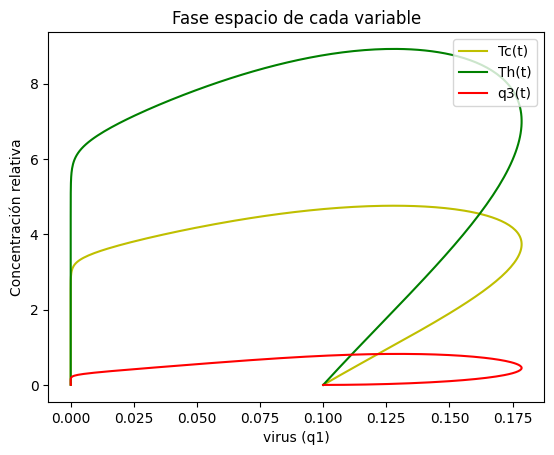

In [23]:
# Diagrama de fase
plt.plot(sol[:,0], sol[:,1], 'y', label='Tc(t)')
plt.plot(sol[:,0], sol[:,2], 'g', label='Th(t)')
plt.plot(sol[:,0], sol[:,3], 'r', label='q3(t)')

plt.xlabel("virus (q1)")
plt.ylabel("Concentración relativa")
plt.legend(loc='upper right')
plt.title("Fase espacio de cada variable")

Diagrama de fase más visual y completo para todos los casos posibles, no para un caso concreto como los otros.

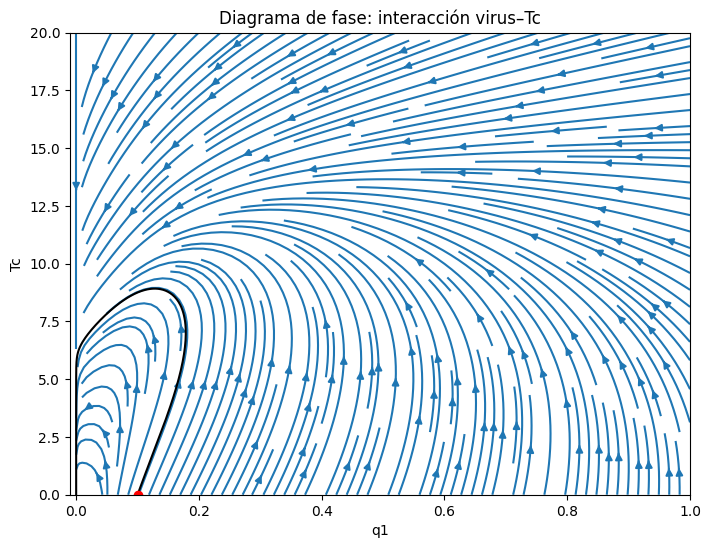

In [24]:
N = 100                                # numero de puntos en cada direccion

q1_start, q1_end = 0, 1            # límites izquierdo y derecho en x
Tc_start, Tc_end = 0, 20.0            # límites izquierdo y derecho en y

q1pts = np.linspace(q1_start, q1_end, N)    # 1D-array con coordenadas en x
Tcpts = np.linspace(Tc_start, Tc_end, N)    # 1D-array con coordenadas en y

QQ, TT = np.meshgrid(q1pts, Tcpts)            # genera las matrices

# Cálculo de las derivadas en todos los puntos de la matriz generada (QQ, TT)
uu = f1M1(QQ) + f1M5(QQ,TT)             # cambio de q1 con el tiempo
vv = ftcM2(QQ,TT) + ftcM6(QQ,TT)        # cambio de Tc con el tiempo

fig, ax = plt.subplots(figsize =(8, 6))
#ax.quiver(TT, YY, vel[0], vel[1])
ax.streamplot(QQ, TT, uu,vv,density=2) # grafica las lineas
ax.set_title("Diagrama de fase: interacción virus–Tc")
ax.set_xlabel("q1")
ax.set_ylabel("Tc")
ax.set_xlim([q1_start-q1_end*0.01,q1_end])


ax.plot(sol[:, 0], sol[:, 2], 'k')                          # trayectoria calculada con ODEINT (negro)
ax.plot(sol[0, 0], sol[0, 2], 'or', label="Inicio")         